# **Titanic Survival Prediction**
# Objective
The objective of this project is to build a machine learning model that predicts whether a passenger survived the Titanic disaster based on features such as age, gender, ticket class, fare, and embarkation point.
# Dataset Description
The Titanic dataset contains information about 891 passengers and 12 columns:

1.  PassengerId
2. Survived
3. Pclass
4. Name
5. Sex
6. Age
7. SibSp
8. Parch
9. Ticket
10. Fare
11. Cabin
12. Embarked

The target variable is:
* Survived

   0 = Did not survive
   
   1 = Survived
# Libraries Used
The following Python libraries were used:
1.   Pandas
2.   NumPy
3. Matplotlib
4. Seaborn
5. Scikit-learn
# Data Preprocessing
The following preprocessing steps were performed:
* Filled missing values in the Age column using the median.
* Filled missing values in the Embarked column using the mode.
* Dropped unnecessary columns such as PassengerId, Name, Ticket, and Cabin.
* Converted categorical variables (Sex and Embarked) into numerical values.
# Machine Learning Algorithm Used
The Decision Tree Classifier algorithm was used to train the model.
# Model Evaluation
The model was evaluated using:
1. Accuracy Score
2. Classification Report
3. Confusion Matrix
4. Heatmap

The model achieved an accuracy of approximately :
79.89%
# Conclusion
A Decision Tree model was successfully built to predict Titanic passenger survival. The model was trained using passenger information such as age, gender, ticket class, and fare. The model achieved nearly 80% accuracy, demonstrating the application of machine learning techniques to classification problems.

In [3]:
import pandas as pd

data = pd.read_csv("Titanic-Dataset.csv")
print(data.head())
print(data.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

Cleaning the data and training the model

In [4]:
# Handle missing values

data["Age"] = data["Age"].fillna(data["Age"].median())
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

# Drop unnecessary columns

data = data.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

# Convert text columns into numbers

data["Sex"] = data["Sex"].map({"male": 0, "female": 1})
data["Embarked"] = data["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# Split data into features and target

X = data.drop("Survived", axis=1)
y = data["Survived"]

# Split into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train the model

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

# Make predictions

y_pred = model.predict(X_test)

# Evaluate the model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7988826815642458

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.83      0.83       105
           1       0.76      0.76      0.76        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179


Confusion Matrix:

[[87 18]
 [18 56]]


Data visualiszation

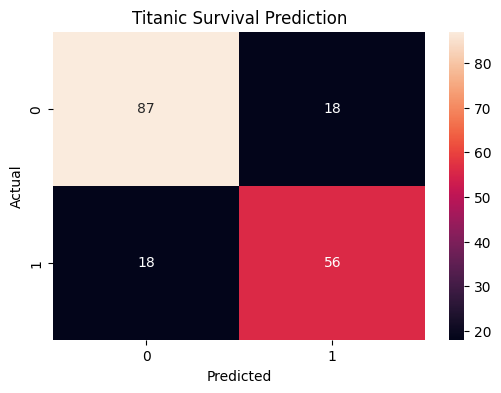

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Titanic Survival Prediction")

plt.show()